In [9]:
%pip install qiskit
%pip install qiskit-aer
%pip install pylatexenc
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


# Redundancy & Stabilizer Measurement

Qubits are fragile and cannot be cloned (no-cloning theorem).  
To protect quantum information, we use entanglement for redundancy.

Two-qubit encoding:
The logical qubit is encoded across two physical qubits using a CNOT gate (control = qubit 0, target = qubit 1).

In [11]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(2,2)
qc.h(0)  
qc.cx(0,1)
qc.measure([0,1],[0,1])
print(qc.draw('text')) 

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


# Encoding Qubits

The 3-bit repetition code is a classical error-correcting code, but we can consider what happens if we try to use it to protect **qubits** against errors. As we'll see, it's not a very impressive quantum error-correcting code, because it actually makes some errors more likely. It is, however, the first step toward the **Shor code**, and will serve us well from a pedagogical viewpoint.

To be clear, when we refer to the 3-bit repetition code being used for qubits, we have in mind an encoding of a qubit where standard basis states are repeated three times. A single-qubit state vector is encoded as follows:

\[
\alpha \lvert 0 \rangle + \beta \lvert 1 \rangle \;\mapsto\; \alpha \lvert 000 \rangle + \beta \lvert 111 \rangle
\]

This encoding is easily implemented by the following quantum circuit, which makes use of **two initialized workspace qubits** and **two controlled-NOT (CNOT) gates**.

In [105]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

#Prepare of qubit
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

# Measure qubits
qc.measure(0,0)
qc.barrier()
qc.measure(1,1)
qc.barrier()
qc.measure(2,2)

#circuit
qc.draw('mpl')
print(qc.draw('text'))

     ┌───┐          ┌─┐ ░     ░    
q_0: ┤ H ├──■────■──┤M├─░─────░────
     └───┘┌─┴─┐  │  └╥┘ ░ ┌─┐ ░    
q_1: ─────┤ X ├──┼───╫──░─┤M├─░────
          └───┘┌─┴─┐ ║  ░ └╥┘ ░ ┌─┐
q_2: ──────────┤ X ├─╫──░──╫──░─┤M├
               └───┘ ║  ░  ║  ░ └╥┘
c: 3/════════════════╩═════╩═════╩═
                     0     1     2 


Notice, in particular, that this encoding is **not the same** as repeating the quantum state three times. That is, it is **not**  

\[
\lvert \psi \rangle \;\mapsto\; \lvert \psi \rangle \lvert \psi \rangle \lvert \psi \rangle
\]

for an unknown quantum state \(\lvert \psi \rangle\). Such an encoding **cannot be implemented** due to the **no-cloning theorem**.

# Bit-Flip Errors

Now suppose that an **error** takes place after the encoding has been performed. Specifically, let's suppose that an \(X\) gate, or in other words a **bit-flip**, occurs on one of the qubits. For instance, if the **middle qubit** experiences a bit-flip, the state of the three qubits is transformed into:

\[
\alpha \lvert 010 \rangle + \beta \lvert 101 \rangle
\]

Of course, this isn't the only sort of error that could occur — and it's also reasonable to question the assumption that an error takes the form of a perfect, unitary operation. We'll return to these issues in the last section of the lesson, and for now we can view an error of this form as **just one possible type of error** (albeit a fundamentally important one).

We can see clearly from the mathematical expression above that the **middle bit** is the one that's different inside of each ket. But suppose that we had the three qubits in our possession and **didn't know their state**.  

If we suspected that a bit-flip may have occurred, one option would be to perform a **standard basis measurement**, which, in the case at hand, would cause us to see either:

\[
010 \quad \text{or} \quad 101
\]

with probabilities \(|\alpha|^2\) and \(|\beta|^2\), respectively. In either case, our conclusion would be that the **middle bit flipped** — but, unfortunately, we would **lose the original quantum state**:

\[
\alpha \lvert 0 \rangle + \beta \lvert 1 \rangle
\]

This is the state we're trying to protect, so **measuring in the standard basis is an unsatisfactory option**.

---

What we can do instead is use the following quantum circuit, **feeding the encoded state into the top three qubits**. This circuit **nondestructively measures the parity** of the standard basis states of:

- The **top two qubits**, and  
- The **bottom two qubits** of the three-qubit encoding.

In [109]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

# Syndrome measurement Z1Z2 and Z2Z3 
qc.cx(0,3)
qc.cx(1,3) 
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3)
qc.measure(4,4) 

#circuit
qc.draw('mpl')
plt.show()
print(qc.draw('text')) 

                          ░       
q_0: ──■──────────────────░───────
       │                  ░       
q_1: ──┼────■────■────────░───────
       │    │    │        ░       
q_2: ──┼────┼────┼────■───░───────
     ┌─┴─┐┌─┴─┐  │    │   ░ ┌─┐   
q_3: ┤ X ├┤ X ├──┼────┼───░─┤M├───
     └───┘└───┘┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐
q_4: ──────────┤ X ├┤ X ├─░──╫─┤M├
               └───┘└───┘ ░  ║ └╥┘
c: 5/════════════════════════╩══╩═
                             3  4 


Under the assumption that at most one bit flipped, one can easily deduce from the measurement outcomes the location of the bit-flip (or the absence of one). In particular, as the following four circuit diagrams illustrate, the measurement outcome 00 indicates that no bit-flip occurred, while the three other possibilities indicate which qubit experienced a bit-flip.

Raw Counts: {'00000': 510, '00111': 514}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 00 -> Syndrome Eigenvalues: [1, 1], Count: 510
Bits: 11 -> Syndrome Eigenvalues: [-1, -1], Count: 514
     ┌───┐           ░                      ░        ░ ┌─┐      
q_0: ┤ H ├──■────■───░───■──────────────────░────────░─┤M├──────
     └───┘┌─┴─┐  │   ░   │                  ░        ░ └╥┘┌─┐   
q_1: ─────┤ X ├──┼───░───┼────■────■────────░────────░──╫─┤M├───
          └───┘┌─┴─┐ ░   │    │    │        ░        ░  ║ └╥┘┌─┐
q_2: ──────────┤ X ├─░───┼────┼────┼────■───░────────░──╫──╫─┤M├
               └───┘ ░ ┌─┴─┐┌─┴─┐  │    │   ░ ┌─┐    ░  ║  ║ └╥┘
q_3: ────────────────░─┤ X ├┤ X ├──┼────┼───░─┤M├────░──╫──╫──╫─
                     ░ └───┘└───┘┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐ ░  ║  ║  ║ 
q_4: ────────────────░───────────┤ X ├┤ X ├─░──╫─┤M├─░──╫──╫──╫─
                     ░           └───┘└───┘ ░  ║ └╥┘ ░  ║  ║  ║ 
c: 5/══════════════════════════════════════════╩══╩═════╩══╩══╩═
                                   

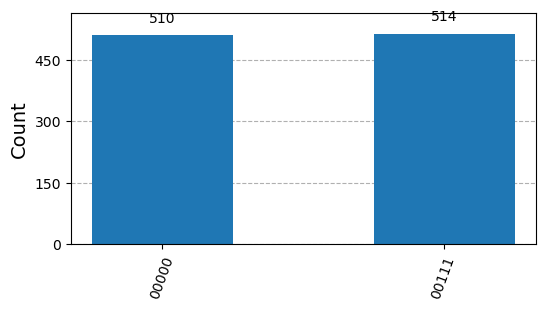

In [114]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode qubit
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.barrier()

#Syndrome measurement
qc.cx(0,3)
qc.cx(1,3)
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3) 
qc.measure(4,4) 
#Measure  qubits 
qc.barrier()
qc.measure(0,0)
qc.measure(1,1)
qc.measure(2,2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
print(qc.draw('text'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Raw Counts: {'01110': 554, '01001': 470}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 10 -> Syndrome Eigenvalues: [-1, 1], Count: 554
Bits: 01 -> Syndrome Eigenvalues: [1, -1], Count: 470
     ┌───┐          ┌───┐ ░                      ░       ┌─┐ ░     ░    
q_0: ┤ H ├──■────■──┤ X ├─░───■──────────────────░───────┤M├─░─────░────
     └───┘┌─┴─┐  │  └───┘ ░   │                  ░       └╥┘ ░ ┌─┐ ░    
q_1: ─────┤ X ├──┼────────░───┼────■────■────────░────────╫──░─┤M├─░────
          └───┘┌─┴─┐      ░   │    │    │        ░        ║  ░ └╥┘ ░ ┌─┐
q_2: ──────────┤ X ├──────░───┼────┼────┼────■───░────────╫──░──╫──░─┤M├
               └───┘      ░ ┌─┴─┐┌─┴─┐  │    │   ░ ┌─┐    ║  ░  ║  ░ └╥┘
q_3: ─────────────────────░─┤ X ├┤ X ├──┼────┼───░─┤M├────╫──░──╫──░──╫─
                          ░ └───┘└───┘┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐ ║  ░  ║  ░  ║ 
q_4: ─────────────────────░───────────┤ X ├┤ X ├─░──╫─┤M├─╫──░──╫──░──╫─
                          ░           └───┘└───┘ ░  ║ └╥┘ ║  ░  ║  ░  ║ 
c: 5/═══════

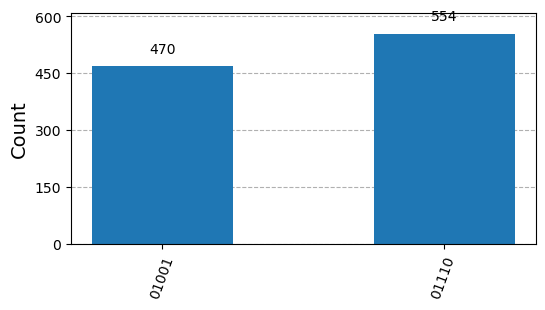

In [115]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc.reset(0)
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.x(0)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0,3)
qc.cx(1,3) 
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3)
qc.measure(4,4) 

#Measure data qubits
qc.measure(0,0)
qc.measure(1,1)
qc.measure(2,2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
print(qc.draw('text'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

In [61]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

# Step 1: Encode logical qubit
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.x(1)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0,3)
qc.cx(1,3) 
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3)
qc.measure(4,4) 

#Measure data qubits
qc.measure(0,0)
qc.barrier()
qc.measure(1,1)
qc.barrier()
qc.measure(2,2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

# Get counts
counts = result.get_counts()  # <-- this was missing
print("Counts:", counts)

#Circuit diagram
qc.draw('mpl')
plt.show()
print(qc.draw('text'))

# Convert ancilla bits to syndrome eigenvalues
print("\nSyndrome Eigenvalues:")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  # last two bits are ancillas
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}")

Counts: {'11010': 502, '11101': 522}
     ┌───┐                ░                      ░       ┌─┐ ░     ░    
q_0: ┤ H ├──■────■────────░───■──────────────────░───────┤M├─░─────░────
     └───┘┌─┴─┐  │  ┌───┐ ░   │                  ░       └╥┘ ░ ┌─┐ ░    
q_1: ─────┤ X ├──┼──┤ X ├─░───┼────■────■────────░────────╫──░─┤M├─░────
          └───┘┌─┴─┐└───┘ ░   │    │    │        ░        ║  ░ └╥┘ ░ ┌─┐
q_2: ──────────┤ X ├──────░───┼────┼────┼────■───░────────╫──░──╫──░─┤M├
               └───┘      ░ ┌─┴─┐┌─┴─┐  │    │   ░ ┌─┐    ║  ░  ║  ░ └╥┘
q_3: ─────────────────────░─┤ X ├┤ X ├──┼────┼───░─┤M├────╫──░──╫──░──╫─
                          ░ └───┘└───┘┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐ ║  ░  ║  ░  ║ 
q_4: ─────────────────────░───────────┤ X ├┤ X ├─░──╫─┤M├─╫──░──╫──░──╫─
                          ░           └───┘└───┘ ░  ║ └╥┘ ║  ░  ║  ░  ║ 
c: 5/═══════════════════════════════════════════════╩══╩══╩═════╩═════╩═
                                                    3  4  0     1     2 

Syndrome Eige

In [62]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.x(2)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0,3)
qc.cx(1,3) 
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3)
qc.measure(4,4) 

#Measure data qubits
qc.measure(0,0)
qc.barrier()
qc.measure(1,1)
qc.barrier()
qc.measure(2,2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

# Get counts
counts = result.get_counts()  # <-- this was missing
print("Counts:", counts)

# Step 6: Circuit diagram
qc.draw('mpl')
plt.show()
print(qc.draw('text'))

# Step 7: Convert ancilla bits to syndrome eigenvalues
print("\nSyndrome Eigenvalues:")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  # last two bits are ancillas
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}")

Counts: {'10100': 522, '10011': 502}
     ┌───┐                ░                      ░       ┌─┐ ░     ░    
q_0: ┤ H ├──■────■────────░───■──────────────────░───────┤M├─░─────░────
     └───┘┌─┴─┐  │        ░   │                  ░       └╥┘ ░ ┌─┐ ░    
q_1: ─────┤ X ├──┼────────░───┼────■────■────────░────────╫──░─┤M├─░────
          └───┘┌─┴─┐┌───┐ ░   │    │    │        ░        ║  ░ └╥┘ ░ ┌─┐
q_2: ──────────┤ X ├┤ X ├─░───┼────┼────┼────■───░────────╫──░──╫──░─┤M├
               └───┘└───┘ ░ ┌─┴─┐┌─┴─┐  │    │   ░ ┌─┐    ║  ░  ║  ░ └╥┘
q_3: ─────────────────────░─┤ X ├┤ X ├──┼────┼───░─┤M├────╫──░──╫──░──╫─
                          ░ └───┘└───┘┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐ ║  ░  ║  ░  ║ 
q_4: ─────────────────────░───────────┤ X ├┤ X ├─░──╫─┤M├─╫──░──╫──░──╫─
                          ░           └───┘└───┘ ░  ║ └╥┘ ║  ░  ║  ░  ║ 
c: 5/═══════════════════════════════════════════════╩══╩══╩═════╩═════╩═
                                                    3  4  0     1     2 

Syndrome Eige

Raw Counts: {'01111': 531, '01000': 493}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 11 -> Syndrome Eigenvalues: [-1, -1], Count: 531
Bits: 00 -> Syndrome Eigenvalues: [1, 1], Count: 493
     ┌───┐          ┌───┐ ░                      ░        ░ ┌───┐ ░ ┌─┐      
q_0: ┤ H ├──■────■──┤ X ├─░───■──────────────────░────────░─┤ X ├─░─┤M├──────
     └───┘┌─┴─┐  │  └───┘ ░   │                  ░        ░ └───┘ ░ └╥┘┌─┐   
q_1: ─────┤ X ├──┼────────░───┼────■────■────────░────────░───────░──╫─┤M├───
          └───┘┌─┴─┐      ░   │    │    │        ░        ░       ░  ║ └╥┘┌─┐
q_2: ──────────┤ X ├──────░───┼────┼────┼────■───░────────░───────░──╫──╫─┤M├
               └───┘      ░ ┌─┴─┐┌─┴─┐  │    │   ░ ┌─┐    ░       ░  ║  ║ └╥┘
q_3: ─────────────────────░─┤ X ├┤ X ├──┼────┼───░─┤M├────░───────░──╫──╫──╫─
                          ░ └───┘└───┘┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐ ░       ░  ║  ║  ║ 
q_4: ─────────────────────░───────────┤ X ├┤ X ├─░──╫─┤M├─░───────░──╫──╫──╫─
                          ░        

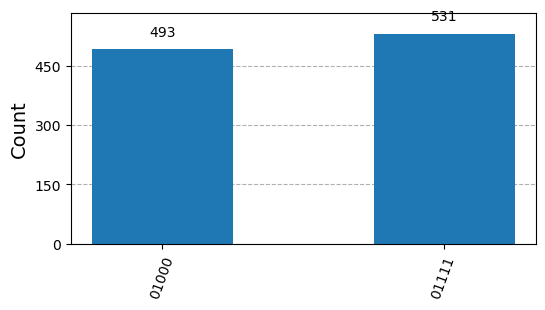

In [79]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)       
qc.cx(0, 1)   
qc.cx(0, 2)
qc.x(0)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
qc.measure(3, 3) 
qc.measure(4, 4) 
qc.barrier()
qc.x(0)
qc.barrier() 

#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
print(qc.draw('text'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Raw Counts: {'11000': 527, '11111': 497}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 00 -> Syndrome Eigenvalues: [1, 1], Count: 527
Bits: 11 -> Syndrome Eigenvalues: [-1, -1], Count: 497
     ┌───┐                ░                      ░        ░       ░ ┌─┐      
q_0: ┤ H ├──■────■────────░───■──────────────────░────────░───────░─┤M├──────
     └───┘┌─┴─┐  │  ┌───┐ ░   │                  ░        ░ ┌───┐ ░ └╥┘┌─┐   
q_1: ─────┤ X ├──┼──┤ X ├─░───┼────■────■────────░────────░─┤ X ├─░──╫─┤M├───
          └───┘┌─┴─┐└───┘ ░   │    │    │        ░        ░ └───┘ ░  ║ └╥┘┌─┐
q_2: ──────────┤ X ├──────░───┼────┼────┼────■───░────────░───────░──╫──╫─┤M├
               └───┘      ░ ┌─┴─┐┌─┴─┐  │    │   ░ ┌─┐    ░       ░  ║  ║ └╥┘
q_3: ─────────────────────░─┤ X ├┤ X ├──┼────┼───░─┤M├────░───────░──╫──╫──╫─
                          ░ └───┘└───┘┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐ ░       ░  ║  ║  ║ 
q_4: ─────────────────────░───────────┤ X ├┤ X ├─░──╫─┤M├─░───────░──╫──╫──╫─
                          ░        

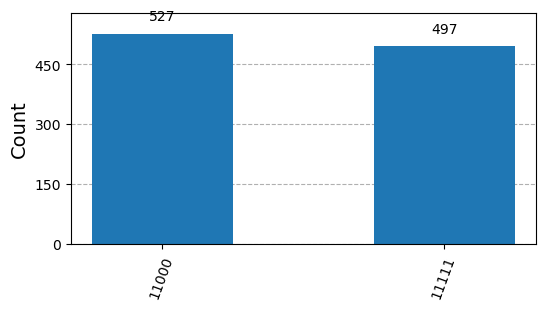

In [78]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)       
qc.cx(0, 1)   
qc.cx(0, 2)
qc.x(1)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
qc.measure(3, 3) 
qc.measure(4, 4) 
qc.barrier()
qc.x(1)
qc.barrier() 

#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
print(qc.draw('text'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Raw Counts: {'10111': 506, '10000': 518}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 11 -> Syndrome Eigenvalues: [-1, -1], Count: 506
Bits: 00 -> Syndrome Eigenvalues: [1, 1], Count: 518
     ┌───┐                ░                      ░        ░       ░ ┌─┐      
q_0: ┤ H ├──■────■────────░───■──────────────────░────────░───────░─┤M├──────
     └───┘┌─┴─┐  │        ░   │                  ░        ░       ░ └╥┘┌─┐   
q_1: ─────┤ X ├──┼────────░───┼────■────■────────░────────░───────░──╫─┤M├───
          └───┘┌─┴─┐┌───┐ ░   │    │    │        ░        ░ ┌───┐ ░  ║ └╥┘┌─┐
q_2: ──────────┤ X ├┤ X ├─░───┼────┼────┼────■───░────────░─┤ X ├─░──╫──╫─┤M├
               └───┘└───┘ ░ ┌─┴─┐┌─┴─┐  │    │   ░ ┌─┐    ░ └───┘ ░  ║  ║ └╥┘
q_3: ─────────────────────░─┤ X ├┤ X ├──┼────┼───░─┤M├────░───────░──╫──╫──╫─
                          ░ └───┘└───┘┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐ ░       ░  ║  ║  ║ 
q_4: ─────────────────────░───────────┤ X ├┤ X ├─░──╫─┤M├─░───────░──╫──╫──╫─
                          ░        

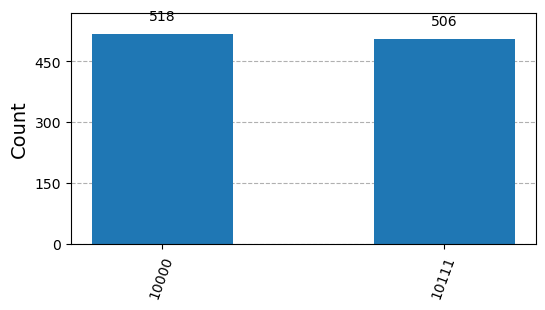

In [77]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)       
qc.cx(0, 1)   
qc.cx(0, 2)
qc.x(2)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
qc.measure(3, 3) 
qc.measure(4, 4) 
qc.barrier()
qc.x(2)
qc.barrier() 

#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
print(qc.draw('text'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Crucially, the state of the top three qubits does not collapse in any of the cases, which allows us to correct a bit-flip error if one has occurred — by simply applying the same bit-flip again with an 
X gate. The following table summarizes the states we obtain from at most one bit-flip, the measurement outcomes (which are called the syndrome in the context of error correction), and the correction needed to get back to the original encoding.

| State                        | Syndrome | Correction         |
|-------------------------------|---------|------------------|
| \(\alpha \lvert 000 \rangle + \beta \lvert 111 \rangle\) | 00      | \(I \otimes I \otimes I\) |
| \(\alpha \lvert 001 \rangle + \beta \lvert 110 \rangle\) | 01      | \(I \otimes I \otimes X\) |
| \(\alpha \lvert 010 \rangle + \beta \lvert 101 \rangle\) | 11      | \(I \otimes X \otimes I\) |
| \(\alpha \lvert 100 \rangle + \beta \lvert 011 \rangle\) | 10      | \(X \otimes I \otimes I\) |

In [ ]:
```
| State                        | Syndrome | Correction         |
|-------------------------------|---------|------------------|
| α|000⟩ + β|111⟩               | 00      | I ⊗ I ⊗ I       |
| α|001⟩ + β|110⟩               | 01      | I ⊗ I ⊗ X       |
| α|010⟩ + β|101⟩               | 11      | I ⊗ X ⊗ I       |
| α|100⟩ + β|011⟩               | 10      | X ⊗ I ⊗ I       |
```